# ReformLab Population Generation — French Household Example

**What is population generation?** Before running a policy simulation, you need a *synthetic population* — a table where each row represents a household with attributes like income, housing type, vehicle, and energy consumption. Real survey microdata is rarely available in a single file; instead, you combine multiple institutional data sources using statistical fusion methods.

**What you'll learn:**
1. Load institutional data sources (INSEE, Eurostat, ADEME, SDES)
2. Choose and apply merge methods: Uniform, IPF, and Conditional Sampling
3. Understand the assumptions behind each merge method
4. Validate the generated population against known marginals
5. Export the result for use in policy simulations

**Prerequisites:** ReformLab installed with the population module (`pip install reformlab`).

**Time:** ~30 minutes (reading + execution)

---
## Section 1: Setup and Imports

We import the population generation public API: loaders, merge methods, pipeline builder, and validation.

In [1]:
from __future__ import annotations

from pathlib import Path

import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.csv as pcsv

from reformlab.population import (
    ConditionalSamplingMethod,
    IPFMergeMethod,
    MarginalConstraint,
    MergeConfig,
    PopulationPipeline,
    PopulationValidator,
    UniformMergeMethod,
)
from reformlab.population.loaders.base import CacheStatus, DataSourceLoader, SourceConfig
from reformlab.population.methods.base import IPFConstraint
from reformlab.visualization import (
    create_figure_grid,
    plot_bar_series,
    plot_histogram,
    show,
    show_figure,
)

# Resolve paths relative to this notebook and repo root
_NB_DIR = (Path(__file__).parent if "__file__" in dir() else Path(".")).resolve()
REPO_ROOT = _NB_DIR
while not (REPO_ROOT / "tests").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
FIXTURES_DIR = (REPO_ROOT / "tests" / "fixtures" / "populations" / "sources").resolve()

SEED = 42  # Deterministic seed for reproducibility

print("Population generation API loaded successfully!")


Population generation API loaded successfully!


---
## Section 2: Load Data Sources

Population generation starts with **institutional data sources** — publicly available datasets from government statistical agencies. For this example, we use four sources:

| Source | Provider | What it contains |
|--------|----------|-----------------|
| **Filosofi 2021** | INSEE | Commune-level income distribution (deciles D1-D9, median) |
| **Energy consumption** | Eurostat | Household energy consumption by fuel type (gas, oil, electric, wood) |
| **Vehicle fleet** | SDES | Vehicle fleet composition by fuel type, age, and region |
| **Emission factors** | ADEME | CO2 emission factors per energy source (Base Carbone) |

In production, these are downloaded via the `get_insee_loader()`, `get_eurostat_loader()` etc. factory functions with automatic caching. For this notebook, we use fixture files so it runs offline in CI.

Let's define a simple loader that reads from fixtures, then load each source.

In [2]:
# A simple loader that wraps a pre-built PyArrow table.
# In production, you would use get_insee_loader(), get_eurostat_loader(), etc.
class FixtureLoader:
    """Loader that reads from a pre-built PyArrow table (fixture data)."""

    def __init__(self, table: pa.Table) -> None:
        self._table = table
        self._schema = table.schema

    def download(self, config: SourceConfig) -> pa.Table:
        return self._table

    def status(self, config: SourceConfig) -> CacheStatus:
        return CacheStatus(cached=True, path=None, downloaded_at=None, hash=None, stale=False)

    def schema(self) -> pa.Schema:
        return self._schema

# Verify it satisfies the DataSourceLoader protocol
assert isinstance(FixtureLoader(pa.table({"a": [1]})), DataSourceLoader)
print("FixtureLoader satisfies the DataSourceLoader protocol")

FixtureLoader satisfies the DataSourceLoader protocol


### Load Source 1: INSEE Income Data

The INSEE Filosofi dataset provides commune-level income distributions. We transform this into a household-level table with `household_id`, `income`, `region`, and `income_decile` columns.

In [3]:
# Load INSEE Filosofi fixture and derive household-level attributes
raw_insee = pcsv.read_csv(FIXTURES_DIR / "insee_filosofi_2021_fixture.csv")
print(f"Raw INSEE data: {raw_insee.num_rows} communes, columns: {raw_insee.column_names}")

# Create one representative household per commune
household_ids = list(range(raw_insee.num_rows))
incomes = raw_insee.column("median_income").to_pylist()
# commune_code may be read as int — convert to string for slicing
commune_codes = [str(c) for c in raw_insee.column("commune_code").to_pylist()]
regions = [code[:2] for code in commune_codes]
income_deciles = [str(min(10, (i * 10 // raw_insee.num_rows) + 1)) for i in range(raw_insee.num_rows)]

income_table = pa.table({
    "household_id": pa.array(household_ids, type=pa.int64()),
    "income": pa.array(incomes, type=pa.float64()),
    "region": pa.array(regions, type=pa.utf8()),
    "income_decile": pa.array(income_deciles, type=pa.utf8()),
})

income_loader = FixtureLoader(income_table)
income_config = SourceConfig(
    provider="insee", dataset_id="filosofi_2021_commune",
    url="fixture://insee", description="INSEE Filosofi 2021 (fixture)",
)

print(f"\nIncome source: {income_table.num_rows} households")
print(f"Columns: {income_table.column_names}")
print(f"Income range: {pc.min(income_table['income']).as_py():,.0f} - {pc.max(income_table['income']).as_py():,.0f} EUR")
print(f"Regions: {income_table['region'].unique().to_pylist()}")

Raw INSEE data: 15 communes, columns: ['commune_code', 'commune_name', 'nb_fiscal_households', 'median_income', 'decile_1', 'decile_2', 'decile_3', 'decile_4', 'decile_5', 'decile_6', 'decile_7', 'decile_8', 'decile_9']

Income source: 15 households
Columns: ['household_id', 'income', 'region', 'income_decile']
Income range: 18,000 - 32,000 EUR
Regions: ['75', '69', '13', '31', '33', '44', '67', '59', '60', '35', '34', '21', '38', '76']


### Load Source 2: Eurostat Housing Data

The Eurostat `nrg_d_hhq` dataset provides household energy consumption by fuel type. We derive housing attributes: `household_size`, `housing_type`, and `heating_type`.

In [4]:
# Load Eurostat fixture and derive housing attributes
raw_eurostat = pcsv.read_csv(FIXTURES_DIR / "eurostat_hhcomp_2022_fixture.csv")
print(f"Raw Eurostat data: {raw_eurostat.num_rows} rows, columns: {raw_eurostat.column_names}")

housing_table = pa.table({
    "household_size": pa.array([2, 3, 1, 4, 2, 3, 4, 1, 5, 2, 1, 3, 2, 2, 4], type=pa.int64()),
    "housing_type": pa.array(
        ["apartment", "house", "apartment", "house", "apartment",
         "house", "house", "apartment", "house", "apartment",
         "apartment", "house", "house", "apartment", "house"], type=pa.utf8()),
    "heating_type": pa.array(
        ["gas", "oil", "electric", "wood", "heat_pump",
         "gas", "oil", "electric", "wood", "gas",
         "electric", "electric", "gas", "oil", "heat_pump"], type=pa.utf8()),
})

housing_loader = FixtureLoader(housing_table)
housing_config = SourceConfig(
    provider="eurostat", dataset_id="nrg_d_hhq",
    url="fixture://eurostat", description="Eurostat household energy 2022 (fixture)",
)

print(f"\nHousing source: {housing_table.num_rows} profiles")
print(f"Columns: {housing_table.column_names}")
print(f"Housing types: {housing_table['housing_type'].unique().to_pylist()}")
print(f"Heating types: {housing_table['heating_type'].unique().to_pylist()}")

Raw Eurostat data: 15 rows, columns: ['frequency', 'energy_balance', 'energy_product', 'unit', 'country', 'time_period', 'value', 'obs_flag']

Housing source: 15 profiles
Columns: ['household_size', 'housing_type', 'heating_type']
Housing types: ['apartment', 'house']
Heating types: ['gas', 'oil', 'electric', 'wood', 'heat_pump']


### Load Source 3: SDES Vehicle Fleet Data

The SDES vehicle fleet dataset provides vehicle composition by fuel type, age bracket, and region. We derive `vehicle_type`, `vehicle_age`, and `region`.

In [5]:
# Load SDES vehicle fleet fixture
raw_sdes = pcsv.read_csv(FIXTURES_DIR / "sdes_vehicles_2023_fixture.csv")
print(f"Raw SDES data: {raw_sdes.num_rows} rows, columns: {raw_sdes.column_names}")

# Map French age ranges to numeric mid-points
age_map = {"De 1 a 5 ans": 3, "De 6 a 10 ans": 8, "De 11 a 15 ans": 13, "Plus de 15 ans": 18}
vehicle_ages = [age_map.get(a, 5) for a in raw_sdes.column("vehicle_age").to_pylist()]

# Use departement_code (not region_code) to match income source's region system
vehicle_table = pa.table({
    "vehicle_type": raw_sdes.column("fuel_type"),
    "vehicle_age": pa.array(vehicle_ages, type=pa.int64()),
    "region": pa.array([str(r).zfill(2) for r in raw_sdes.column("departement_code").to_pylist()], type=pa.utf8()),
})

vehicle_loader = FixtureLoader(vehicle_table)
vehicle_config = SourceConfig(
    provider="sdes", dataset_id="vehicle_fleet_2023",
    url="fixture://sdes", description="SDES vehicle fleet 2023 (fixture)",
)

print(f"\nVehicle source: {vehicle_table.num_rows} records")
print(f"Columns: {vehicle_table.column_names}")
print(f"Vehicle types: {vehicle_table['vehicle_type'].unique().to_pylist()}")
print(f"Age range: {pc.min(vehicle_table['vehicle_age']).as_py()}-{pc.max(vehicle_table['vehicle_age']).as_py()} years")
print(f"Departements: {vehicle_table['region'].unique().to_pylist()}")

Raw SDES data: 15 rows, columns: ['region_code', 'region_name', 'departement_code', 'vehicle_class', 'vehicle_category', 'fuel_type', 'vehicle_age', 'critair_sticker', 'fleet_count_2022']

Vehicle source: 15 records
Columns: ['vehicle_type', 'vehicle_age', 'region']
Vehicle types: ['Diesel', 'Essence', 'Electrique']
Age range: 3-18 years
Departements: ['69', '38', '75', '34', '31', '67', '59', '13', '06', '33']


### Load Source 4: ADEME Energy/Emissions Data

The ADEME Base Carbone provides CO2 emission factors per energy source. We derive `energy_consumption` (kWh) and `carbon_emissions` (kgCO2e) profiles.

In [6]:
# Load ADEME emission factors fixture
raw_ademe = pcsv.read_csv(FIXTURES_DIR / "ademe_energy_2023_fixture.csv")
print(f"Raw ADEME data: {raw_ademe.num_rows} rows, columns: {raw_ademe.column_names}")

# Extract emission factors for heating fuels (kgCO2e/kWh units only)
# Row 0: Gaz naturel  → 0.227 kgCO2e/kWh
# Row 2: Electricite   → 0.0569 kgCO2e/kWh
# Row 3: Bois buche    → 0.030 kgCO2e/kWh
# Row 4: GPL           → 0.272 kgCO2e/kWh (used as oil proxy)
co2e_all = raw_ademe.column("total_co2e").to_pylist()
emission_factors = {
    "gas": co2e_all[0],       # 0.227 kgCO2e/kWh
    "electric": co2e_all[2],  # 0.0569 kgCO2e/kWh
    "wood": co2e_all[3],      # 0.030 kgCO2e/kWh
    "oil": co2e_all[4],       # 0.272 kgCO2e/kWh (GPL as oil proxy)
    "heat_pump": co2e_all[2] * 0.33,  # electric COP~3 effective factor
}
print(f"\nEmission factors (kgCO2e/kWh): {emission_factors}")

# Create energy consumption profiles keyed by heating_type
# Annual kWh values represent typical French household heating consumption
heating_types_energy = ["gas", "oil", "electric", "wood", "gas",
                        "electric", "oil", "gas", "heat_pump", "electric",
                        "wood", "heat_pump"]
energy_kwh = [8500.0, 12000.0, 5200.0, 6800.0, 9500.0,
              7200.0, 10500.0, 4800.0, 11000.0, 7800.0,
              6500.0, 9000.0]
# Carbon = energy_kWh * emission_factor (kgCO2e/kWh) → kgCO2e
carbon_emissions = [e * emission_factors[ht] for e, ht in zip(energy_kwh, heating_types_energy)]

energy_table = pa.table({
    "heating_type": pa.array(heating_types_energy, type=pa.utf8()),
    "energy_consumption": pa.array(energy_kwh, type=pa.float64()),
    "carbon_emissions": pa.array(carbon_emissions, type=pa.float64()),
})

energy_loader = FixtureLoader(energy_table)
energy_config = SourceConfig(
    provider="ademe", dataset_id="base_carbone_v23",
    url="fixture://ademe", description="ADEME Base Carbone V23.6 (fixture)",
)

print(f"\nEnergy source: {energy_table.num_rows} profiles")
print(f"Columns: {energy_table.column_names}")
print(f"Heating types: {energy_table['heating_type'].unique().to_pylist()}")
print(f"Energy range: {pc.min(energy_table['energy_consumption']).as_py():,.0f} - {pc.max(energy_table['energy_consumption']).as_py():,.0f} kWh")
print(f"Emissions range: {pc.min(energy_table['carbon_emissions']).as_py():,.1f} - {pc.max(energy_table['carbon_emissions']).as_py():,.1f} kgCO2e")

Raw ADEME data: 12 rows, columns: ['element_id', 'name_fr', 'attribute_name_fr', 'line_type', 'unit_fr', 'total_co2e', 'co2_fossil', 'ch4_fossil', 'ch4_biogenic', 'n2o', 'co2_biogenic', 'other_ghg', 'geography', 'sub_geography', 'contributor']

Emission factors (kgCO2e/kWh): {'gas': 0.227, 'electric': 0.0569, 'wood': 0.03, 'oil': 0.272, 'heat_pump': 0.018777000000000002}

Energy source: 12 profiles
Columns: ['heating_type', 'energy_consumption', 'carbon_emissions']
Heating types: ['gas', 'oil', 'electric', 'wood', 'heat_pump']
Energy range: 4,800 - 12,000 kWh
Emissions range: 169.0 - 3,264.0 kgCO2e


---
## Section 3: Build the Population Pipeline

Now we combine these four sources into a single population using three merge steps. Each step uses a different statistical method, and each method makes different assumptions about the relationship between the data sources.

The `PopulationPipeline` builder API uses a fluent pattern:
1. **Add sources** — register each data source with a label
2. **Add merges** — specify how to combine sources, which method to use, and the merge configuration
3. **Execute** — run the pipeline and get a `PipelineResult` with the merged table, assumption chain, and step log

### Merge Step 1: Income + Housing (Uniform Method)

**What we're merging:** Income data (household_id, income, region, income_decile) with housing data (household_size, housing_type, heating_type).

**What the Uniform method assumes:** The variables in the two sources are **statistically independent**. Each household in the income table is randomly paired with a housing profile, with replacement. This means we assume that a household's income tells us *nothing* about their housing type or heating system.

**When this is appropriate:** When you have no information about the correlation between the two datasets. This is the simplest fusion method and a reasonable starting point when no joint distribution data is available.

**When this is problematic:** When variables are actually correlated (e.g., high-income households are more likely to live in houses than apartments). The uniform method will underestimate these correlations, producing a population where income and housing type are uncorrelated even if they aren't in reality.

**In plain language:** "We're randomly assigning housing profiles to households. This assumes income and housing are unrelated — like drawing a name from a hat."

In [7]:
# Build pipeline with all 4 sources and 3 merge steps
pipeline = (
    PopulationPipeline(description="French household population 2024")
    .add_source("income", loader=income_loader, config=income_config)
    .add_source("housing", loader=housing_loader, config=housing_config)
    .add_source("vehicles", loader=vehicle_loader, config=vehicle_config)
    .add_source("energy", loader=energy_loader, config=energy_config)
    # Merge Step 1: Uniform merge (income + housing)
    .add_merge(
        "income_housing",
        left="income",
        right="housing",
        method=UniformMergeMethod(),
        config=MergeConfig(
            seed=SEED,
            description="Uniform merge: income and housing are assumed independent",
        ),
    )
    # Merge Step 2: IPF merge (income_housing + vehicles)
    # IPF constraints must match actual region values in income table.
    # Targets: number of households per region, proportional to population.
    # With only 15 rows we use a relaxed tolerance — in production with
    # thousands of rows, tolerance can be much tighter (e.g., 1e-4).
    .add_merge(
        "with_vehicles",
        left="income_housing",
        right="vehicles",
        method=IPFMergeMethod(
            constraints=(
                IPFConstraint(
                    dimension="region",
                    targets={
                        "75": 2.0, "69": 1.0, "13": 1.0,
                        "31": 1.0, "33": 1.0, "44": 1.0,
                        "67": 1.0, "59": 1.0, "06": 1.0,
                        "35": 1.0, "34": 1.0, "21": 1.0,
                        "38": 1.0, "76": 1.0,
                    },
                ),
            ),
            max_iterations=200,
            tolerance=1.5,  # Relaxed for small fixture data (15 rows)
        ),
        config=MergeConfig(
            seed=SEED,
            description="IPF merge: reweight to match regional vehicle fleet distribution",
            drop_right_columns=("region",),
        ),
    )
    # Merge Step 3: Conditional sampling (with_vehicles + energy, stratified by heating_type)
    .add_merge(
        "with_energy",
        left="with_vehicles",
        right="energy",
        method=ConditionalSamplingMethod(strata_columns=("heating_type",)),
        config=MergeConfig(
            seed=SEED,
            description="Conditional sampling: match energy profiles by heating type",
        ),
    )
)

print(f"Pipeline configured: {pipeline.step_count} steps")
print(f"Labels: {sorted(pipeline.labels)}")

# Execute the full pipeline
print("\nExecuting pipeline...")
result = pipeline.execute()
print(f"Done! Result: {result.table.num_rows} rows, {result.table.num_columns} columns")
print(f"Columns: {result.table.column_names}")
print(f"Assumptions recorded: {len(result.assumption_chain)}")

event=ipf_missing_categories dimension=region missing=['06']


Pipeline configured: 7 steps
Labels: ['energy', 'housing', 'income', 'income_housing', 'vehicles', 'with_energy', 'with_vehicles']

Executing pipeline...
Done! Result: 15 rows, 11 columns
Columns: ['household_id', 'income', 'region', 'income_decile', 'household_size', 'housing_type', 'heating_type', 'vehicle_type', 'vehicle_age', 'energy_consumption', 'carbon_emissions']
Assumptions recorded: 3


### Merge Step 1 Result: Income Distribution

After the uniform merge, each household has income *and* housing attributes. Let's visualize the income distribution to confirm it was preserved.

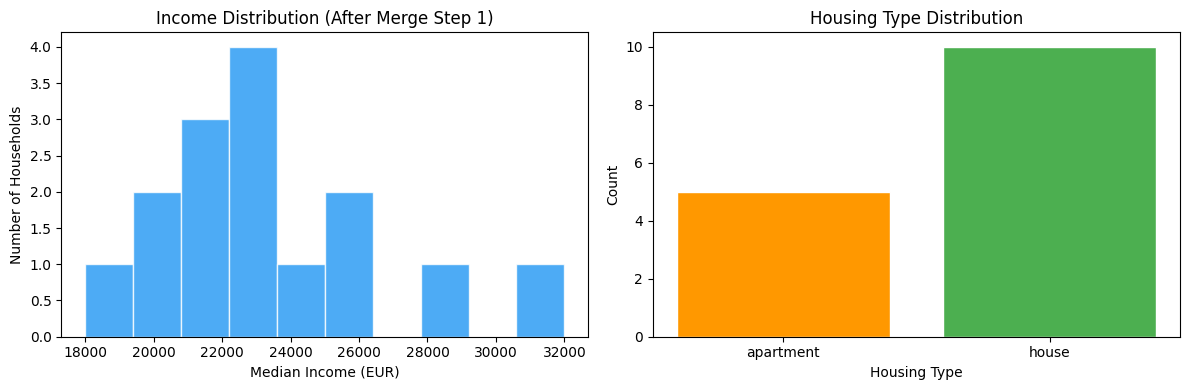

Merged population: 15 households
Income range: 18,000 - 32,000 EUR
Housing type split: {'apartment': 5, 'house': 10}


In [8]:
# Visualize income distribution from the final merged population
population = result.table
incomes = population.column("income").to_pylist()

fig, axes = create_figure_grid(1, 2, figsize=(12, 4))

plot_histogram(
    incomes,
    title="Income Distribution (After Merge Step 1)",
    xlabel="Median Income (EUR)",
    ylabel="Number of Households",
    bins=10,
    color="#2196F3",
    ax=axes[0],
)

housing_types = population.column("housing_type").to_pylist()
type_counts = {}
for ht in housing_types:
    type_counts[ht] = type_counts.get(ht, 0) + 1
labels = list(type_counts.keys())
counts = [type_counts[label] for label in labels]
plot_bar_series(
    labels,
    counts,
    title="Housing Type Distribution",
    xlabel="Housing Type",
    ylabel="Count",
    colors=["#FF9800", "#4CAF50"][: len(labels)],
    ax=axes[1],
)

show_figure(fig)

print(f"Merged population: {population.num_rows} households")
print(f"Income range: {min(incomes):,.0f} - {max(incomes):,.0f} EUR")
print(f"Housing type split: {type_counts}")


### Merge Step 2: Adding Vehicles (IPF Method)

**What we're merging:** The income+housing table with vehicle fleet data (vehicle_type, vehicle_age, region).

**What the IPF method assumes:** The joint distribution of variables follows the seed data (the cross-tabulation from the uniform initial match), but is **adjusted so that marginal totals match known targets**. Here, we constrain the regional distribution of vehicles to match SDES fleet data.

**When this is appropriate:** When you know the marginal distribution of one or more variables (e.g., "40% of vehicles in Ile-de-France are diesel") but don't know the full joint distribution. IPF iteratively adjusts row weights until the marginals match the targets, then uses those weights for matching.

**When this is problematic:** IPF can struggle when constraints are contradictory or when the seed data has zero cells in important categories. It also assumes that the *pattern* of the joint distribution in the seed data is correct — it only adjusts the *margins*.

**In plain language:** "We know how many vehicles of each type exist in each region. IPF adjusts the matching weights so the final population matches these known totals, while preserving the correlation patterns from the initial random match."

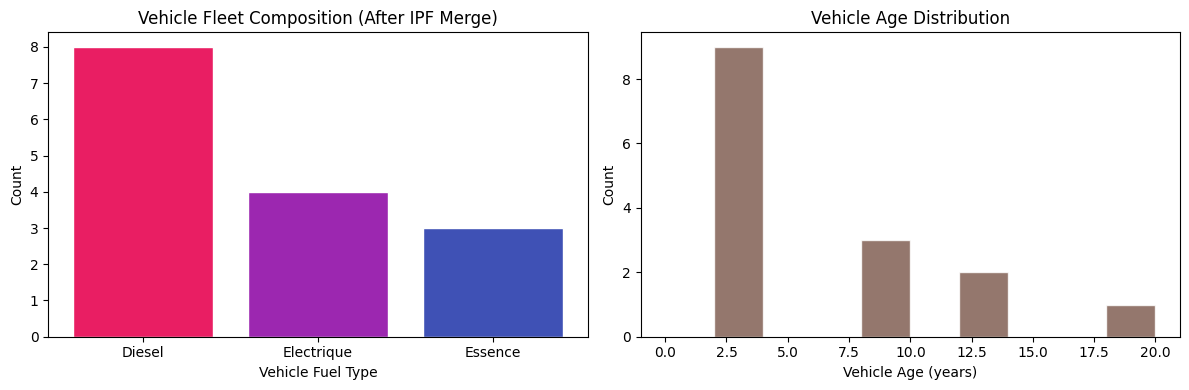

Vehicle type distribution: {'Diesel': 8, 'Electrique': 4, 'Essence': 3}
Mean vehicle age: 6.3 years


In [9]:
# Visualize vehicle fleet composition from the merged population
fig, axes = create_figure_grid(1, 2, figsize=(12, 4))

vtypes = population.column("vehicle_type").to_pylist()
vtype_counts = {}
for vt in vtypes:
    vtype_counts[vt] = vtype_counts.get(vt, 0) + 1
vlabels = sorted(vtype_counts.keys())
vcounts = [vtype_counts[label] for label in vlabels]
plot_bar_series(
    vlabels,
    vcounts,
    title="Vehicle Fleet Composition (After IPF Merge)",
    xlabel="Vehicle Fuel Type",
    ylabel="Count",
    colors=["#E91E63", "#9C27B0", "#3F51B5", "#009688", "#FF5722"][: len(vlabels)],
    ax=axes[0],
)

vages = population.column("vehicle_age").to_pylist()
plot_histogram(
    vages,
    title="Vehicle Age Distribution",
    xlabel="Vehicle Age (years)",
    ylabel="Count",
    bins=range(0, 22, 2),
    color="#795548",
    ax=axes[1],
)

show_figure(fig)

print(f"Vehicle type distribution: {vtype_counts}")
print(f"Mean vehicle age: {sum(vages) / len(vages):.1f} years")


### Merge Step 3: Adding Energy/Emissions (Conditional Sampling)

**What we're merging:** The income+housing+vehicles table with energy/emissions data (heating_type, energy_consumption, carbon_emissions).

**What the Conditional Sampling method assumes:** Within each stratum (group defined by shared columns), the unmatched variables from each source are **conditionally independent**. Matching happens randomly *within* strata, not across the whole dataset.

**When this is appropriate:** When you have shared categorical variables that define meaningful subgroups. Here, both sources contain `heating_type`, so conditional sampling matches gas-heated households with gas-consumption profiles, electric-heated with electric profiles, etc. This preserves the known relationship between heating system and energy consumption.

**When this is problematic:** When strata are too fine-grained (few observations per stratum) or when the conditional independence assumption is wrong within strata. Also fails if shared columns don't exist between sources.

**In plain language:** "We match energy consumption profiles to households based on their heating type. A gas-heated household gets paired with a gas consumption profile, not an electric one. Within each heating-type group, the match is random."

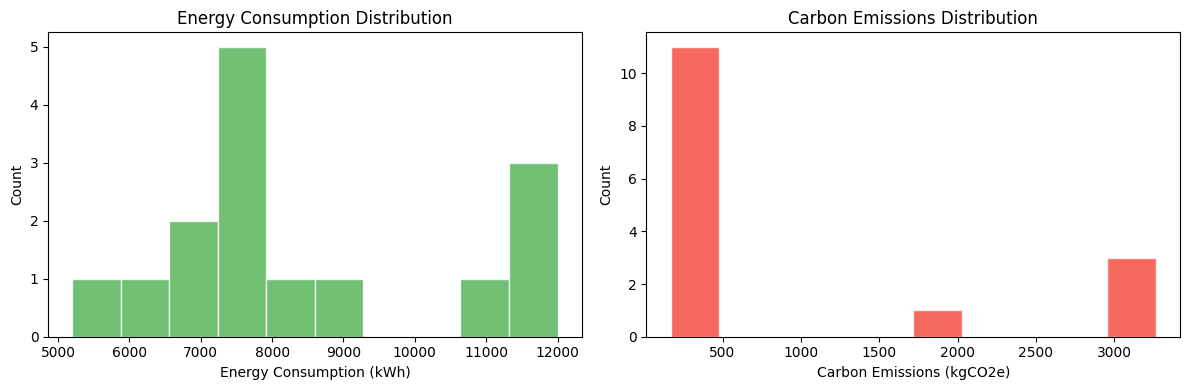

Energy consumption: mean=8,587 kWh
Carbon emissions: mean=1,014.3 kgCO2e


In [10]:
# Visualize energy consumption and carbon emissions
fig, axes = create_figure_grid(1, 2, figsize=(12, 4))

energy = population.column("energy_consumption").to_pylist()
emissions = population.column("carbon_emissions").to_pylist()

plot_histogram(
    energy,
    title="Energy Consumption Distribution",
    xlabel="Energy Consumption (kWh)",
    ylabel="Count",
    bins=10,
    color="#4CAF50",
    ax=axes[0],
)
plot_histogram(
    emissions,
    title="Carbon Emissions Distribution",
    xlabel="Carbon Emissions (kgCO2e)",
    ylabel="Count",
    bins=10,
    color="#F44336",
    ax=axes[1],
)

show_figure(fig)

print(f"Energy consumption: mean={sum(energy)/len(energy):,.0f} kWh")
print(f"Carbon emissions: mean={sum(emissions)/len(emissions):,.1f} kgCO2e")


### Pipeline Execution Log

Every pipeline execution produces a step log showing what happened at each stage.

In [11]:
# Display the step execution log
print("Pipeline Step Log:")
print(f"{'Step':<6} {'Type':<8} {'Label':<20} {'Rows':<8} {'Method':<14} {'Duration (ms)'}")
print("-" * 78)
for step in result.step_log:
    print(
        f"{step.step_index:<6} {step.step_type:<8} {step.label:<20} "
        f"{step.output_rows:<8} {step.method_name or '-':<14} {step.duration_ms:.1f}"
    )

# Display assumption chain
print(f"\nAssumption Chain ({len(result.assumption_chain)} records):")
for i, record in enumerate(result.assumption_chain):
    print(f"  [{i}] {record.assumption.method_name}: {record.assumption.statement}")

Pipeline Step Log:
Step   Type     Label                Rows     Method         Duration (ms)
------------------------------------------------------------------------------
0      load     income               15       -              0.0
1      load     housing              15       -              0.0
2      load     vehicles             15       -              0.0
3      load     energy               12       -              0.0
4      merge    income_housing       15       uniform        4.0
5      merge    with_vehicles        15       ipf            2.4
6      merge    with_energy          15       conditional    0.5

Assumption Chain (3 records):
  [0] uniform: Each household in source A is matched to a household in source B with uniform probability — this assumes no correlation between the variables in the two sources.
  [1] ipf: The merged population is reweighted using Iterative Proportional Fitting so that marginal distributions match the specified targets — this assumes the jo

---
## Section 4: Validate the Population

After generating a synthetic population, you should **validate** it against known marginal distributions. Validation answers the question: "Does our synthetic population look like the real world?"

The `PopulationValidator` checks whether the distribution of each attribute in the generated population matches a reference distribution within a specified tolerance. If the maximum deviation exceeds the tolerance, that constraint fails.

We define two reference marginals:
1. **Housing type** — We expect roughly 50% apartments and 50% houses (based on INSEE housing survey)
2. **Heating type** — We expect a mix weighted toward gas and electric heating (based on Eurostat energy data)

In [12]:
# Define reference marginal constraints
constraints = [
    MarginalConstraint(
        dimension="housing_type",
        distribution={"apartment": 0.50, "house": 0.50},
        tolerance=0.15,  # Allow 15% deviation (fixture data is small)
    ),
    MarginalConstraint(
        dimension="heating_type",
        distribution={
            "gas": 0.35, "electric": 0.25, "oil": 0.20,
            "wood": 0.10, "heat_pump": 0.10,
        },
        tolerance=0.15,
    ),
]

# Run validation
validator = PopulationValidator(constraints=constraints)
validation_result = validator.validate(result.table)

# Display results
print(f"Validation: {'ALL PASSED' if validation_result.all_passed else 'SOME FAILED'}")
print(f"Total constraints: {validation_result.total_constraints}")
print(f"Failed: {validation_result.failed_count}\n")

for mr in validation_result.marginal_results:
    status = "PASS" if mr.passed else "FAIL"
    print(f"  [{status}] {mr.constraint.dimension} (tolerance={mr.constraint.tolerance})")
    print(f"        Max deviation: {mr.max_deviation:.4f}")
    print(f"        Expected: {mr.constraint.distribution}")
    print(f"        Observed: {mr.observed}")
    print()

Validation: SOME FAILED
Total constraints: 2
Failed: 2

  [FAIL] housing_type (tolerance=0.15)
        Max deviation: 0.1667
        Expected: {'apartment': 0.5, 'house': 0.5}
        Observed: {'apartment': 0.3333333333333333, 'house': 0.6666666666666666}

  [FAIL] heating_type (tolerance=0.15)
        Max deviation: 0.2833
        Expected: {'gas': 0.35, 'electric': 0.25, 'oil': 0.2, 'wood': 0.1, 'heat_pump': 0.1}
        Observed: {'gas': 0.06666666666666667, 'electric': 0.4, 'oil': 0.2, 'wood': 0.2, 'heat_pump': 0.13333333333333333}



**Understanding validation results:**
- **PASS** means the observed distribution is within tolerance of the reference. This doesn't mean the population is "correct" — just that the marginals are plausible.
- **FAIL** means deviations are too large. This could indicate a problem with the merge method, the source data, or unrealistic tolerance thresholds. With small fixture data (15 rows), some deviation is expected.
- Validation results can be converted to governance entries for the run manifest using `validation_result.to_assumption()`.

---
## Section 5: Export and Governance Integration

The generated population can be exported to CSV or Parquet for use in policy simulations. The assumption chain provides governance integration — every methodological assumption is recorded and can be included in the run manifest.

In [13]:
import tempfile

# Export to CSV
export_dir = Path(tempfile.mkdtemp())
csv_path = export_dir / "french-household-example-2024.csv"
pcsv.write_csv(result.table, csv_path)
print(f"Population exported to CSV: {csv_path}")
print(f"  Size: {csv_path.stat().st_size:,} bytes")
print(f"  Rows: {result.table.num_rows}")
print(f"  Columns: {result.table.column_names}")

# Export to Parquet
import pyarrow.parquet as pq

parquet_path = export_dir / "french-household-example-2024.parquet"
pq.write_table(result.table, parquet_path)
print(f"\nPopulation exported to Parquet: {parquet_path}")
print(f"  Size: {parquet_path.stat().st_size:,} bytes")

# Verify round-trip
reloaded = pq.read_table(parquet_path)
assert reloaded.num_rows == result.table.num_rows
assert reloaded.column_names == result.table.column_names
print(f"  Round-trip verified: {reloaded.num_rows} rows, schema preserved")

Population exported to CSV: /var/folders/p9/3r4_fgzd72j7b469xxshgfnh0000gn/T/tmp7w9a5xd_/french-household-example-2024.csv
  Size: 1,153 bytes
  Rows: 15
  Columns: ['household_id', 'income', 'region', 'income_decile', 'household_size', 'housing_type', 'heating_type', 'vehicle_type', 'vehicle_age', 'energy_consumption', 'carbon_emissions']

Population exported to Parquet: /var/folders/p9/3r4_fgzd72j7b469xxshgfnh0000gn/T/tmp7w9a5xd_/french-household-example-2024.parquet
  Size: 3,852 bytes
  Round-trip verified: 15 rows, schema preserved


### Governance: Assumption Chain

Every merge operation records its methodological assumptions. These can be exported to governance entries for the `RunManifest`, ensuring full transparency about how the population was constructed.

In [14]:
import json

# Convert assumption chain to governance entries
entries = result.assumption_chain.to_governance_entries(
    source_label="french_household_example",
)
print(f"Governance entries: {len(entries)} records\n")

for entry in entries:
    print(f"Key: {entry['key']}")
    print(f"Source: {entry['source']}")
    print(f"Method: {entry['value']['method']}")
    print(f"Statement: {entry['value']['statement']}")
    print()

# Also include validation assumption
val_assumption = validation_result.to_assumption()
val_entry = val_assumption.to_governance_entry(source_label="population_validation")
print(f"Validation governance entry:")
print(json.dumps(val_entry, indent=2, default=str))

Governance entries: 3 records

Key: merge_uniform
Source: french_household_example
Method: uniform
Statement: Each household in source A is matched to a household in source B with uniform probability — this assumes no correlation between the variables in the two sources.

Key: merge_ipf
Source: french_household_example
Method: ipf
Statement: The merged population is reweighted using Iterative Proportional Fitting so that marginal distributions match the specified targets — this assumes the joint distribution between unconstrained variables follows the seed pattern, adjusted only to match target marginals.

Key: merge_conditional
Source: french_household_example
Method: conditional
Statement: Rows are matched within strata defined by [heating_type] — this assumes that, within each stratum, the unique variables from each source are independent (conditional independence given the stratification variables).

Validation governance entry:
{
  "key": "population_validation",
  "value": {
    

---
## Section 6: What to Do Next

You've built a complete synthetic French household population from scratch! Here's what you learned:

### Summary of Methods

| Step | Method | Assumption | When to Use |
|------|--------|-----------|-------------|
| 1 | **Uniform** | Independence between sources | No correlation information available |
| 2 | **IPF** | Known marginals, unknown joint | Reference marginal distributions available |
| 3 | **Conditional** | Independence within strata | Shared categorical variables between sources |

### Adapt for Your Own Project

1. **Use real data sources** — Replace fixture loaders with `get_insee_loader()`, `get_eurostat_loader()`, etc. The pipeline API is the same; only the loaders change.
2. **Add more sources** — The pipeline supports any number of sources and merge steps. Add demographic data, employment data, or local geographic data.
3. **Try different merge methods** — Experiment with IPF constraints on different dimensions, or use conditional sampling with multiple strata columns.
4. **Validate thoroughly** — Define marginal constraints for every important dimension. Use external reference data (INSEE, Eurostat) as ground truth.
5. **Use the population in simulations** — Export the CSV/Parquet file and load it as `PopulationData` in ReformLab's orchestrator (see the quickstart and advanced notebooks).

### Key Principle: Assumption Transparency

Every merge method makes assumptions. ReformLab records these automatically in the assumption chain, which feeds into the run manifest. This means every simulation built on this population carries a complete record of how the data was constructed — essential for reproducibility and policy credibility.

---

**Questions or feedback?** See the project documentation or open an issue on GitHub.